In [210]:
import pandas as pd
import numpy as np

import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import (
    BisectingKMeans,
    DBSCAN,
    AgglomerativeClustering,
    HDBSCAN
)

mpl.rcParams.update(mpl.rcParamsDefault)
plt.style.use("default")

sns.set_theme(
    style="whitegrid",
    palette="tab10",
    context="notebook"
)

In [211]:
df = pd.read_csv('../../data/Mall_Customers.csv')

In [212]:
df

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
...,...,...,...,...,...
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18


In [213]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [214]:
# удаляем ID
df = df.drop(columns=["CustomerID"])

# кодируем Gender
df["Gender"] = df["Gender"].map({"Male": 0, "Female": 1})

# масштабирование
scaler = StandardScaler()
X = scaler.fit_transform(df)

In [215]:
df

,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,0,19,15,39
1,0,21,15,81
2,1,20,16,6
3,1,23,16,77
4,1,31,17,40
...,...,...,...,...
195,1,35,120,79
196,1,45,126,28
197,0,32,126,74
198,0,32,137,18


In [216]:
bk = BisectingKMeans(n_clusters=5, random_state=42)
labels_bk = bk.fit_predict(X)

df["Cluster_Bisect"] = labels_bk

In [217]:
agg = AgglomerativeClustering(n_clusters=5, linkage="average")
labels_agg = agg.fit_predict(X)

df["Cluster_Agg"] = labels_agg

In [218]:
db = DBSCAN(eps=0.8, min_samples=5)
labels_db = db.fit_predict(X)

df["Cluster_DBSCAN"] = labels_db

In [219]:
df

,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster_Bisect,Cluster_Agg,Cluster_DBSCAN
0,0,19,15,39,1,0,-1
1,0,21,15,81,1,0,0
2,1,20,16,6,4,2,-1
3,1,23,16,77,3,1,1
4,1,31,17,40,4,2,1
...,...,...,...,...,...,...,...
195,1,35,120,79,3,1,1
196,1,45,126,28,4,2,-1
197,0,32,126,74,0,0,-1
198,0,32,137,18,0,3,-1


In [220]:
df[['Cluster_Agg', 'Cluster_Bisect', 'Cluster_DBSCAN']].nunique()

Cluster_Agg       5
Cluster_Bisect    5
Cluster_DBSCAN    6
dtype: int64

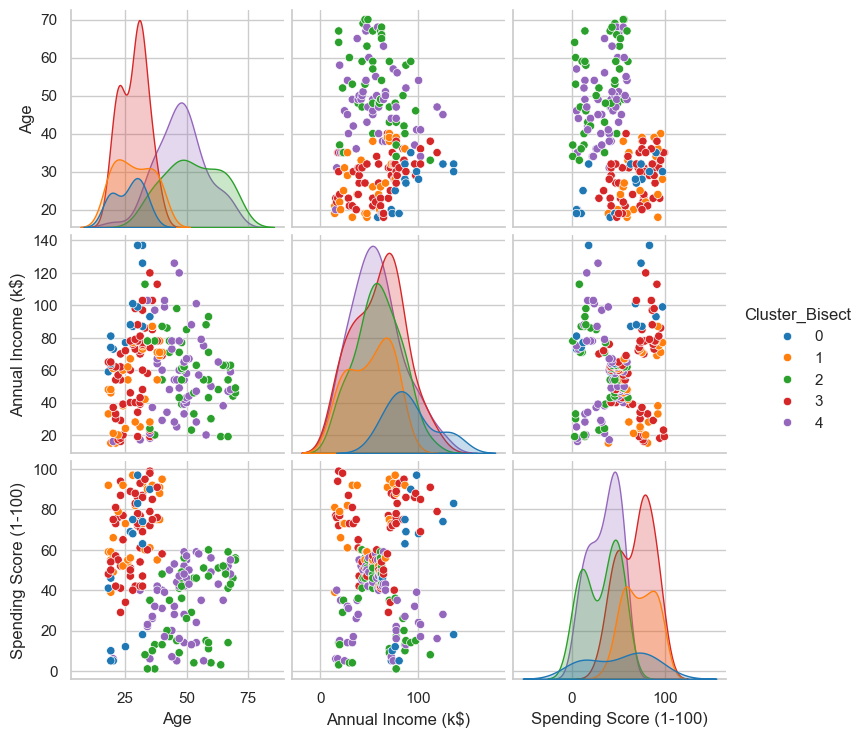

In [221]:
sns.pairplot(
    df,
    vars=["Age", "Annual Income (k$)", "Spending Score (1-100)"],
    hue="Cluster_Bisect",
    palette="tab10"
)

plt.show()

In [222]:
df

,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster_Bisect,Cluster_Agg,Cluster_DBSCAN
0,0,19,15,39,1,0,-1
1,0,21,15,81,1,0,0
2,1,20,16,6,4,2,-1
3,1,23,16,77,3,1,1
4,1,31,17,40,4,2,1
...,...,...,...,...,...,...,...
195,1,35,120,79,3,1,1
196,1,45,126,28,4,2,-1
197,0,32,126,74,0,0,-1
198,0,32,137,18,0,3,-1


In [223]:
X_2d = df[["Annual Income (k$)", "Spending Score (1-100)"]]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_2d)

In [224]:
bk = BisectingKMeans(n_clusters=5, random_state=42)
labels_bk = bk.fit_predict(X_scaled)
df["Cluster_Bisect_2D"] = labels_bk

In [225]:
agg = AgglomerativeClustering(n_clusters=5, linkage="ward")
labels_agg = agg.fit_predict(X_scaled)
df["Cluster_Agg_2D"] = labels_agg

In [251]:
db = DBSCAN(eps=0.37, min_samples=5)
labels_db = db.fit_predict(X_scaled)
df["Cluster_DBSCAN_2D"] = labels_db

In [252]:
hdb = HDBSCAN(min_cluster_size=10, min_samples=5, copy=True)

labels_hdb = hdb.fit_predict(X_scaled)
df["Cluster_HDBSCAN_2D"] = labels_hdb

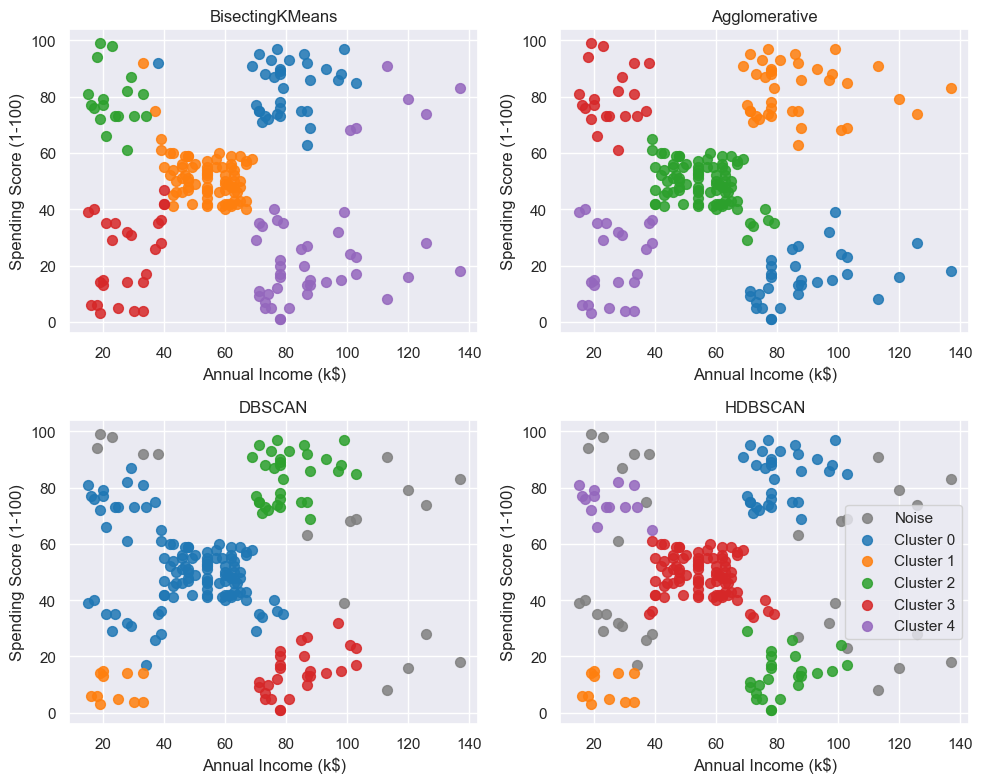

In [253]:
sns.set_theme(style="darkgrid", palette="tab10")

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes = axes.flatten()  # чтобы удобно итерироваться

models = [
    ("BisectingKMeans", "Cluster_Bisect_2D"),
    ("Agglomerative", "Cluster_Agg_2D"),
    ("DBSCAN", "Cluster_DBSCAN_2D"),
    ("HDBSCAN", "Cluster_HDBSCAN_2D"),
]

palette = sns.color_palette("tab10")

for ax, (title, col) in zip(axes, models):
    labels = df[col].values
    unique_labels = np.unique(labels)

    for lab in unique_labels:
        mask = labels == lab
        ax.scatter(
            df.loc[mask, "Annual Income (k$)"],
            df.loc[mask, "Spending Score (1-100)"],
            s=50,
            alpha=0.85,
            label="Noise" if lab == -1 else f"Cluster {lab}",
            color="gray" if lab == -1 else palette[int(lab) % 10]
        )

    ax.set_title(title)
    ax.set_xlabel("Annual Income (k$)")
    ax.set_ylabel("Spending Score (1-100)")

# Легенду оставим только у последнего графика (чище выглядит)
axes[-1].legend()

plt.tight_layout()
plt.show()

In [254]:
df

,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster_Bisect,Cluster_Agg,Cluster_DBSCAN,Cluster_Bisect_2D,Cluster_Agg_2D,Cluster_DBSCAN_2D,Cluster_HDBSCAN_2D
0,0,19,15,39,1,0,-1,3,4,0,-1
1,0,21,15,81,1,0,0,2,3,0,4
2,1,20,16,6,4,2,-1,3,4,1,1
3,1,23,16,77,3,1,1,2,3,0,4
4,1,31,17,40,4,2,1,3,4,0,-1
...,...,...,...,...,...,...,...,...,...,...,...
195,1,35,120,79,3,1,1,4,1,-1,-1
196,1,45,126,28,4,2,-1,4,0,-1,-1
197,0,32,126,74,0,0,-1,4,1,-1,-1
198,0,32,137,18,0,3,-1,4,0,-1,-1


In [255]:
from sklearn.metrics import silhouette_score

print("Bisect:", silhouette_score(X_scaled, df["Cluster_Bisect_2D"]))
print("Agg:", silhouette_score(X_scaled, df["Cluster_Agg_2D"]))

mask_db = df["Cluster_DBSCAN_2D"] != -1
print("DBSCAN:", silhouette_score(X_scaled[mask_db],
                                  df.loc[mask_db, "Cluster_DBSCAN_2D"]))

Bisect: 0.4806844782504286
Agg: 0.5538089226688662
DBSCAN: 0.488417032349414


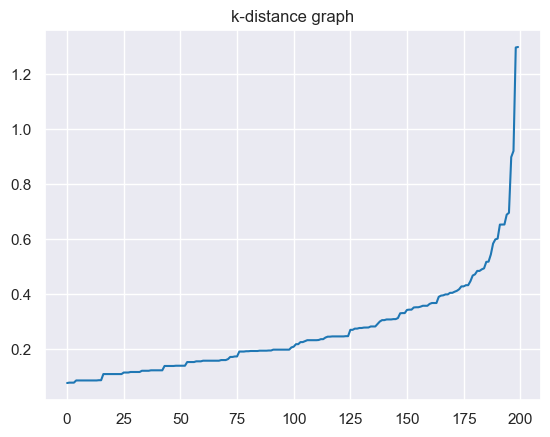

In [256]:
from sklearn.neighbors import NearestNeighbors
import numpy as np
import matplotlib.pyplot as plt

neighbors = NearestNeighbors(n_neighbors=5)
neighbors_fit = neighbors.fit(X_scaled)
distances, indices = neighbors_fit.kneighbors(X_scaled)

distances = np.sort(distances[:, 4])  # 5-й сосед
plt.plot(distances)
plt.title("k-distance graph")
plt.show()

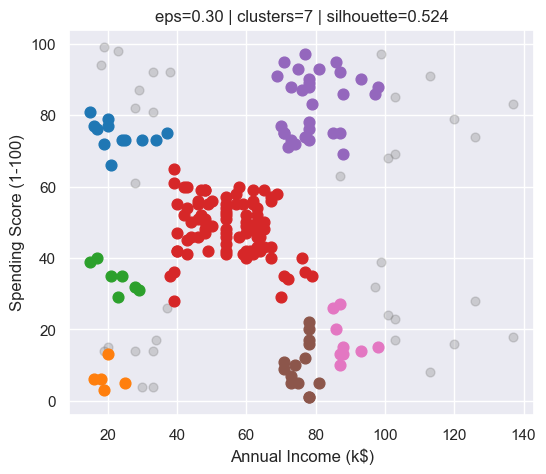

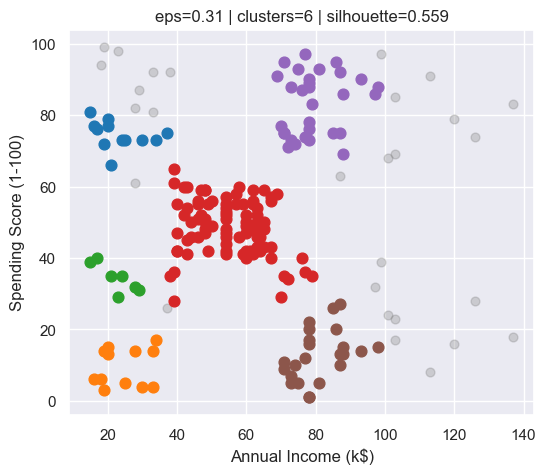

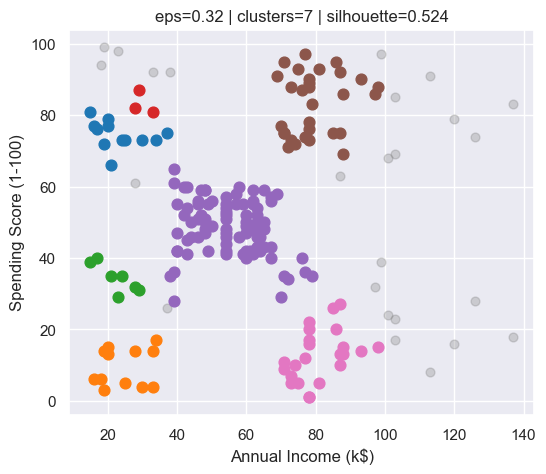

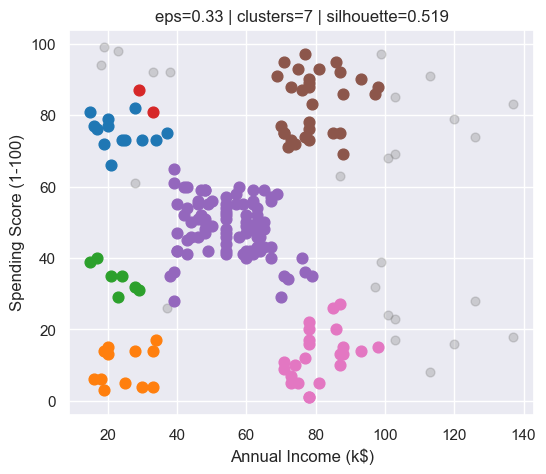

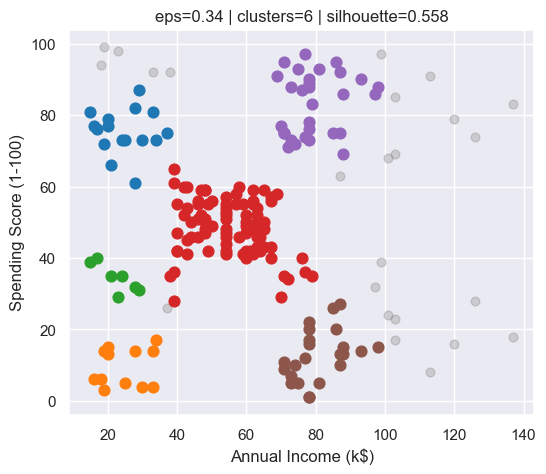

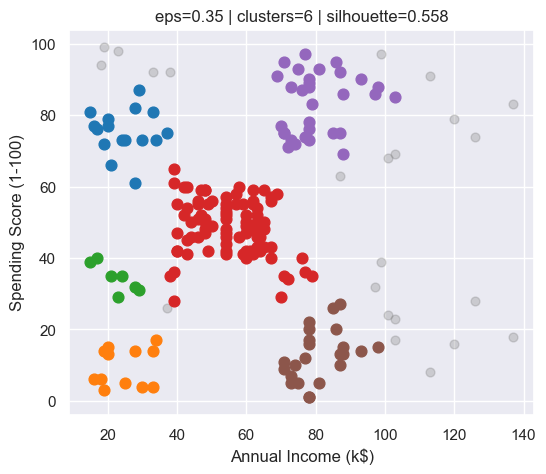

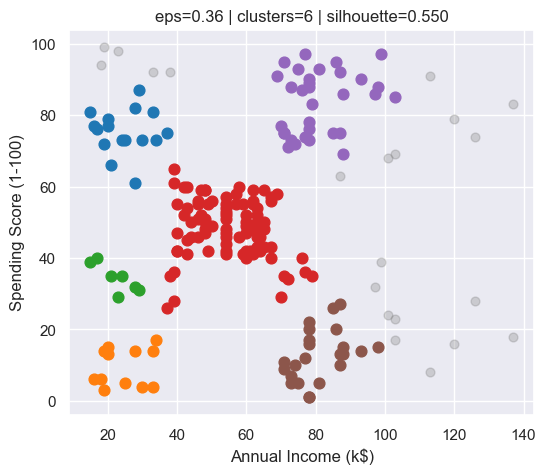

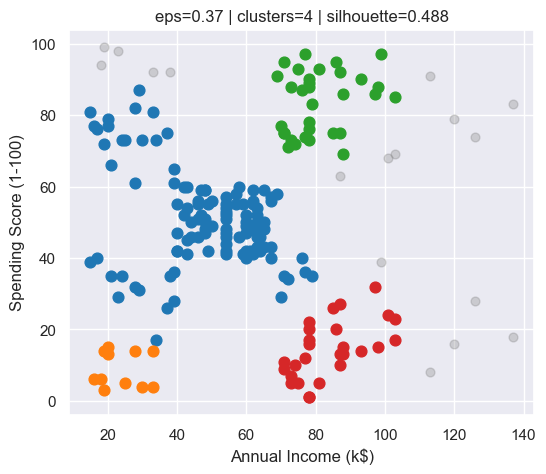

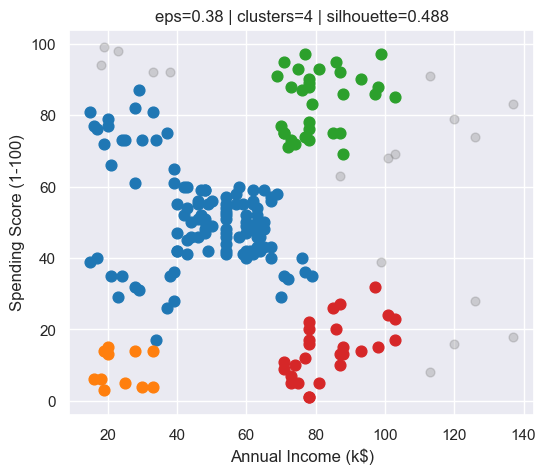

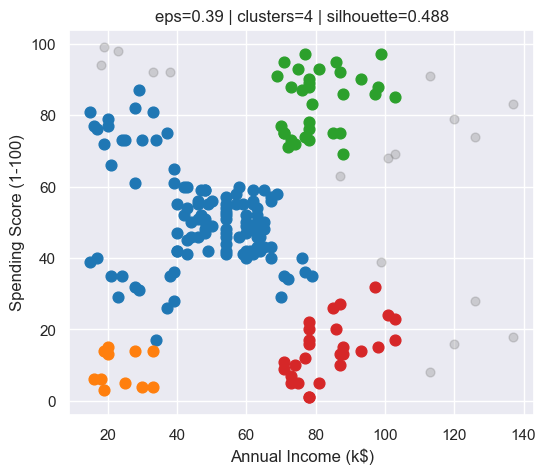

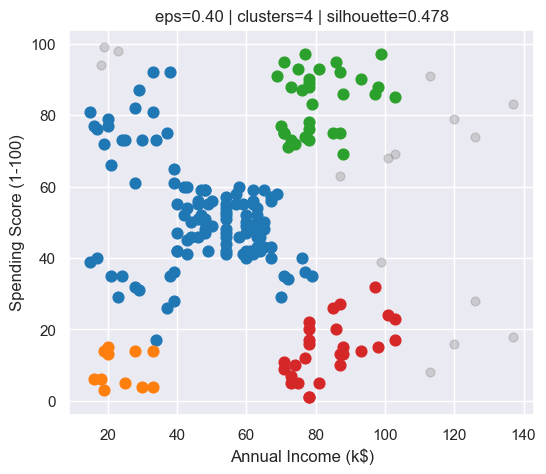

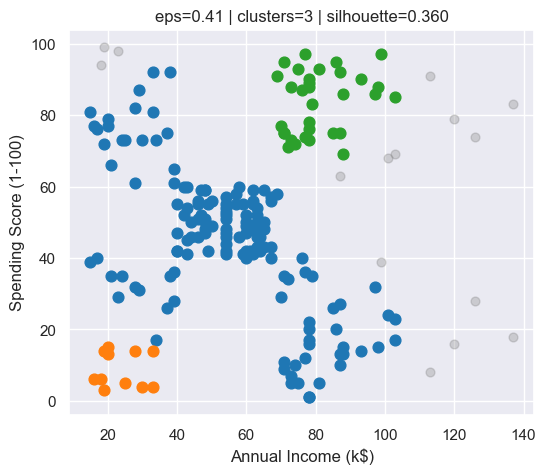

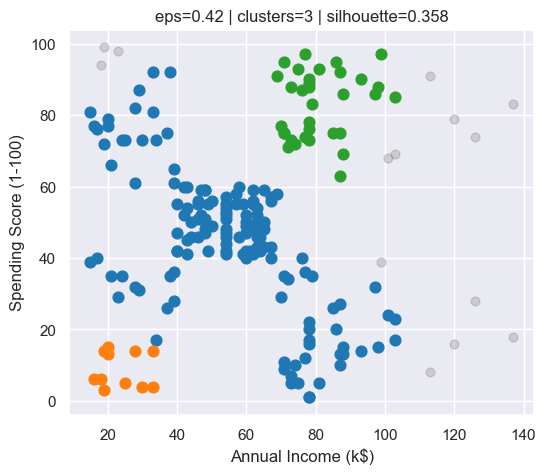

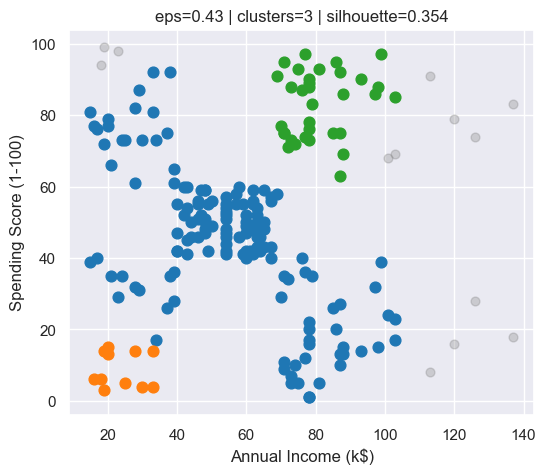

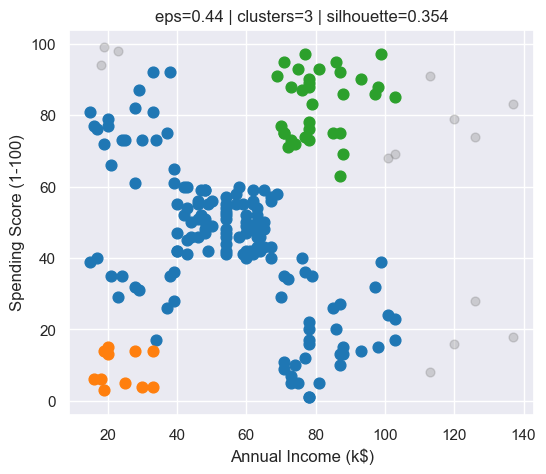

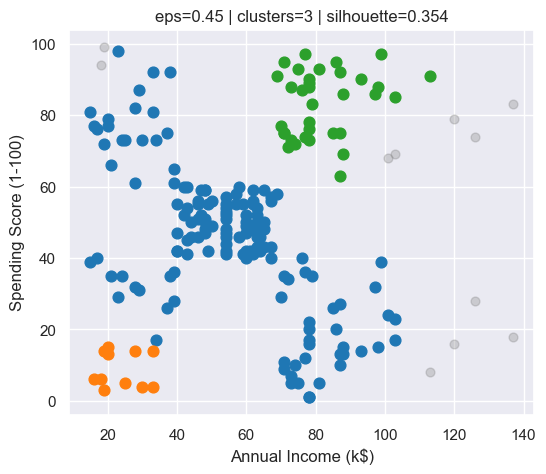

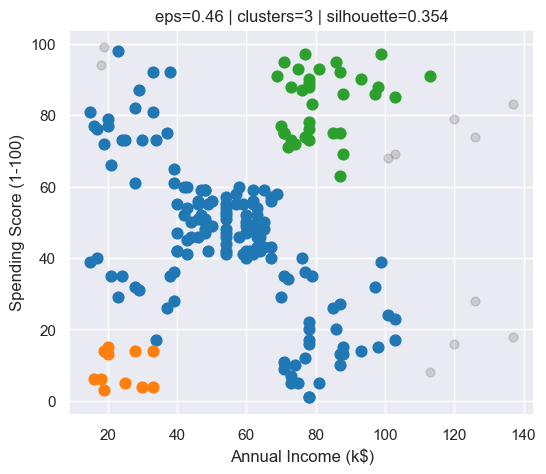

In [257]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score

eps_values = np.arange(0.30, 0.46, 0.01)

for eps in eps_values:
    db = DBSCAN(eps=eps, min_samples=5)
    labels = db.fit_predict(X_scaled)

    clusters = len(set(labels)) - (1 if -1 in labels else 0)

    plt.figure(figsize=(6, 5))

    for lab in np.unique(labels):
        mask = labels == lab

        if lab == -1:
            plt.scatter(
                df.loc[mask, "Annual Income (k$)"],
                df.loc[mask, "Spending Score (1-100)"],
                color="gray",
                alpha=0.3,
                s=40
            )
        else:
            plt.scatter(
                df.loc[mask, "Annual Income (k$)"],
                df.loc[mask, "Spending Score (1-100)"],
                s=60
            )

    title = f"eps={eps:.2f} | clusters={clusters}"

    if clusters > 1:
        mask = labels != -1
        score = silhouette_score(X_scaled[mask], labels[mask])
        title += f" | silhouette={score:.3f}"

    plt.title(title)
    plt.xlabel("Annual Income (k$)")
    plt.ylabel("Spending Score (1-100)")
    plt.show()

In [268]:
import numpy as np

a = np.array([[1, 2, 3], [2, 4, 5], [6, 8, 9]])
b = np.array([1, 2, 3])

result = []


def matrix_dot_vector(a: list[list[int | float]], b: list[int | float]) -> list[int | float]:
    # Return a list where each element is the dot product of a row of 'a' with 'b'.
    # If the number of columns in 'a' does not match the length of 'b', return -1.

    result = []

    for row in a:
        if len(row) != len(b):
            return [-1]

        result.a(sum(row * b))

    return result


# matrix_dot_vector(a, b)

a @ b

array([14, 25, 49])

In [274]:
a = [[1, 2],
     [3, 4],
     [5, 6]]

result = []

for col in range(len(a[0])):
    new_row = []
    for row in range(len(a)):
        new_row.append(a[row][col])

    result.append(new_row)

print(result)


[[1, 3, 5], [2, 4, 6]]
